# **Project 1 CS 250**

## By Xavier Hector and Kyle Moyo

##### 

As we looked over our hobbies from exercise 1, we notice that we had a few things in common. We looked through kaggle and decided to go with a dataset of UEFA Champions League Player Statistics. It looks at a list of players and their statistics for the 2013 to 2020 Champions League season:

Each row will have 103 unique stats you can look at (Eg. No of Goals Scored, Passing accuracy in %, Minutes Played etc)


<a href= "https://www.kaggle.com/datasets/sarangpurandare/uefa-champions-league-player-statistics"> Link to Data</a>

##### 
At the start of the project, our goal was to predict the number of goals that a player will score the following season given features that are correlated to goals in the current season using linear regression. 

We soon found out that the layout of the data would complicate this objective. 

#### Imports 

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns

In [2]:
data = pd.read_csv("/Users/hecto129039/Downloads/UEFA_CL_Player_stats.csv")
data.head()


,Unnamed: 0,name,season,season year,team,rating,goals,bigChancesCreated,bigChancesMissed,assists,...,scoringFrequency,yellowRedCards,savesCaught,savesParried,totalOwnHalfPasses,totalOppositionHalfPasses,totwAppearances,appearances,substitutionsIn,substitutionsOut
0,0,Robin van Persie,Champions League 13/14,13/14,manchester-united,NaN,4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,NaN
1,1,Ashley Cole,Champions League 13/14,13/14,chelsea,NaN,0,NaN,NaN,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,5,0.0,1.0
2,2,José Antonio Reyes,UEFA Champions League 15/16,15/16,sevilla,7.25,0,0.0,1.0,0.0,...,NaN,0.0,0.0,0.0,23.0,68.0,NaN,2,NaN,NaN
3,3,Roman Weidenfeller,Champions League 13/14,13/14,borussia-dortmund,NaN,0,NaN,NaN,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,9,0.0,0.0
4,4,Roman Weidenfeller,Champions League 14/15,14/15,borussia-dortmund,NaN,0,NaN,NaN,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,7,0.0,0.0


##### We decided not to drop the NaN values in our dataset. Upon closer inspection, we noticed that certain players appear in multiple rows because they participated in different seasons. Some of these rows contain missing values for specific statistics (such as goals or assists) for a given year.

##### If we were to drop all rows with NaN values, we would lose entire player-season records, which would reduce the completeness of our data and limit our ability to visualize trends and performance changes over time. Therefore, we kept the NaN values and handled them appropriately during analysis and visualization instead of removing them completely. 

In [3]:
data = data.fillna(0)
data.head()

,Unnamed: 0,name,season,season year,team,rating,goals,bigChancesCreated,bigChancesMissed,assists,...,scoringFrequency,yellowRedCards,savesCaught,savesParried,totalOwnHalfPasses,totalOppositionHalfPasses,totwAppearances,appearances,substitutionsIn,substitutionsOut
0,0,Robin van Persie,Champions League 13/14,13/14,manchester-united,0.00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,0.0,0.0
1,1,Ashley Cole,Champions League 13/14,13/14,chelsea,0.00,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,0.0,1.0
2,2,José Antonio Reyes,UEFA Champions League 15/16,15/16,sevilla,7.25,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,23.0,68.0,0.0,2,0.0,0.0
3,3,Roman Weidenfeller,Champions League 13/14,13/14,borussia-dortmund,0.00,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.0,0.0
4,4,Roman Weidenfeller,Champions League 14/15,14/15,borussia-dortmund,0.00,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,0.0,0.0


In [4]:
data.shape

(5733, 109)

##### At this point, we realized that the dataset represents the total number of players who participated in the UEFA Champions League (UCL) from 2013 to 2020. Therefore, predicting the number of goals a player would score would not make sense, since not all players in the dataset have scored goals.

In soccer, there are 11 different positions on the field, each with unique roles that influence how a player’s performance is measured:

##### - **Forwards (offensive players)**: Typically positioned closest to the opponent’s goal, their main responsibility is to score.

##### - **Midfielders**: They are primarily involved in creating scoring opportunities and linking the defense and attack.

##### - **Defenders**: Their role is to prevent the opposition from scoring and to protect their team’s goal.

Given these positional differences, we decided to change our approach and apply k-means clustering to predict a player’s position based on specific performance related features. We selected variables typically associated with offensive players and aimed to determine whether a player in the dataset is likely to be a forward or not.

##### We graphed the top goal scorers for the UCL seasons from 2013 - 2020

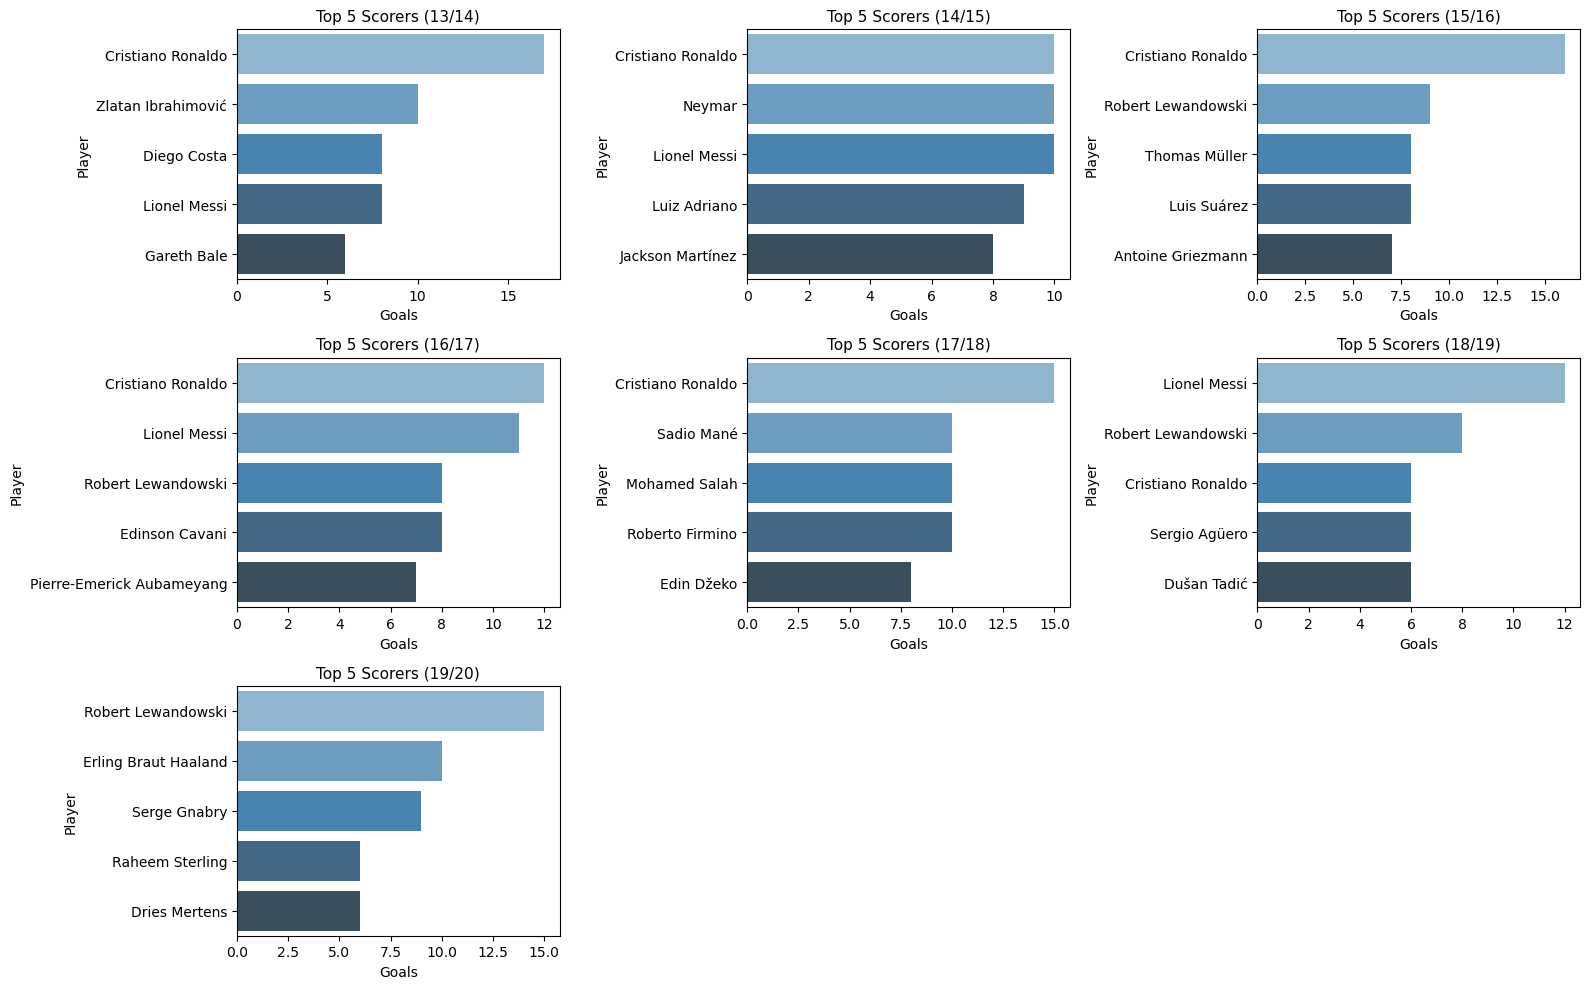

In [5]:
# Define the seasons you want to plot
selected_seasons = ['13/14', '14/15', '15/16', '16/17', '17/18', '18/19', '19/20']

# Filter data for selected seasons
subset = data[data['season year'].isin(selected_seasons)].copy()

# Convert Goals column to numeric in case it's stored as text
subset['goals'] = pd.to_numeric(subset['goals'], errors='coerce')

# Create subplots (3x3 grid)
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

# Plot each season
for i, season in enumerate(selected_seasons):
    season_data = (
        subset[subset['season year'] == season]
        .sort_values('goals', ascending=False)
        .head(5)
    )
    
    sns.barplot(ax=axes[i], data=season_data, x='goals', y='name',hue= 'name', palette='Blues_d', legend =False)
    axes[i].set_title(f"Top 5 Scorers ({season})", fontsize=11)
    axes[i].set_xlabel("Goals")
    axes[i].set_ylabel("Player")

# Remove any unused subplots
for j in range(len(selected_seasons), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


##### We graphed the top players who assisted for the UCL seasons from 2013 - 2020

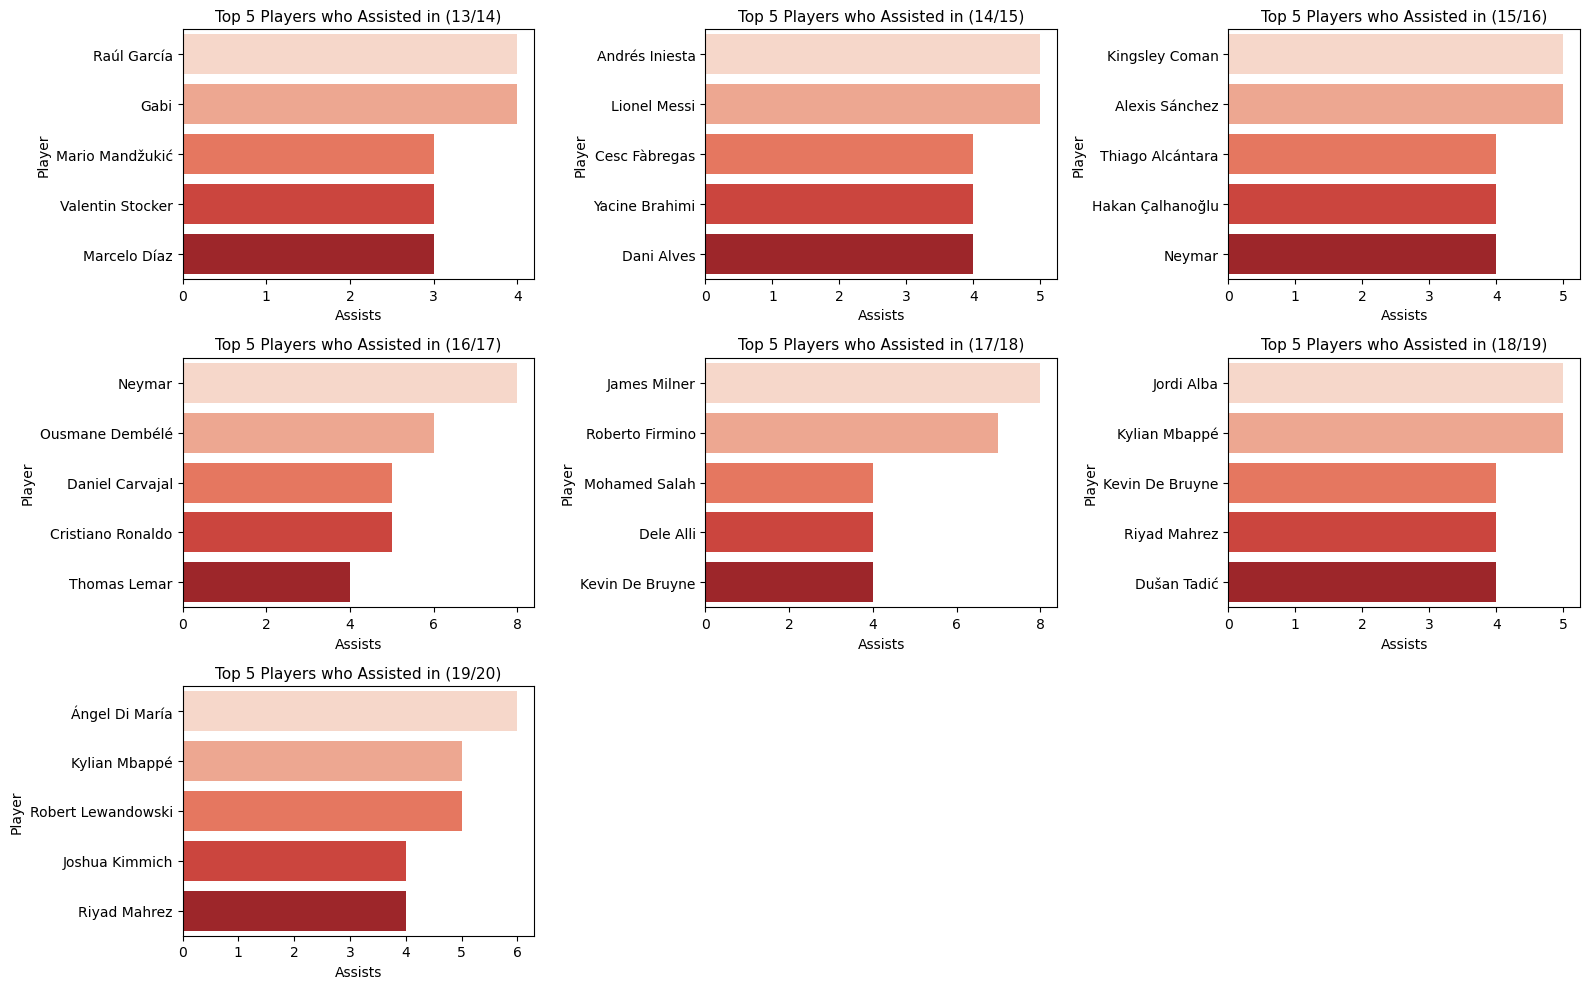

In [6]:
# Define the seasons you want to plot
selected_seasons = ['13/14', '14/15', '15/16', '16/17', '17/18', '18/19', '19/20']

# Filter data for selected seasons
subset = data[data['season year'].isin(selected_seasons)].copy()

# Convert Assists column to numeric in case it's stored as text
subset['assists'] = pd.to_numeric(subset['assists'], errors='coerce')

# Create subplots (3x3 grid)
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

# Plot each season
for i, season in enumerate(selected_seasons):
    season_data = (
        subset[subset['season year'] == season]
        .sort_values('assists', ascending=False)
        .head(5)
    )
    
    sns.barplot(ax=axes[i], data=season_data, x='assists', y='name',hue= 'name', palette='Reds', legend =False)
    axes[i].set_title(f"Top 5 Players who Assisted in ({season})", fontsize=11)
    axes[i].set_xlabel("Assists")
    axes[i].set_ylabel("Player")

# Remove any unused subplots
for j in range(len(selected_seasons), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


##### We also looked at the correlation between number of apperances and goals scored 

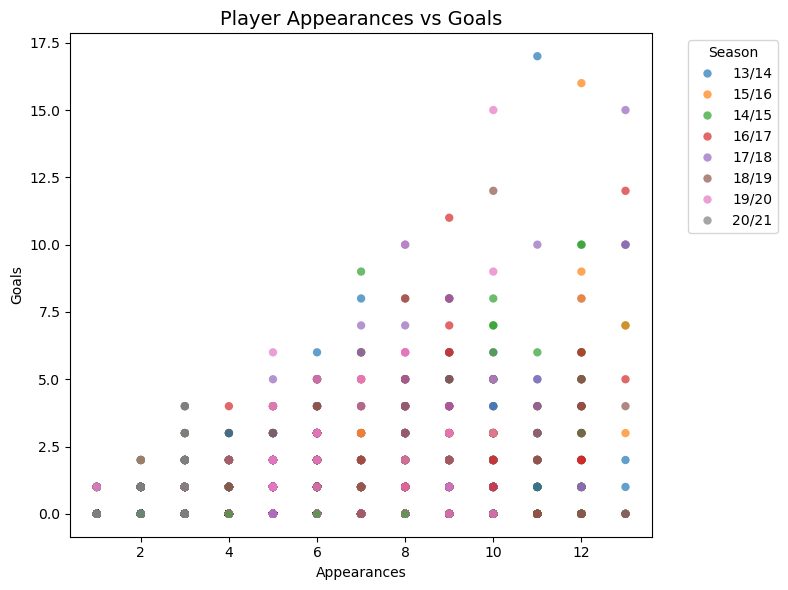

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='appearances', y='goals', hue='season year', palette='tab10', alpha=0.7, edgecolor='none')

plt.title("Player Appearances vs Goals", fontsize=14)
plt.xlabel("Appearances")
plt.ylabel("Goals")
plt.legend(title="Season", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### And the one between Shots on Target and Goals scored

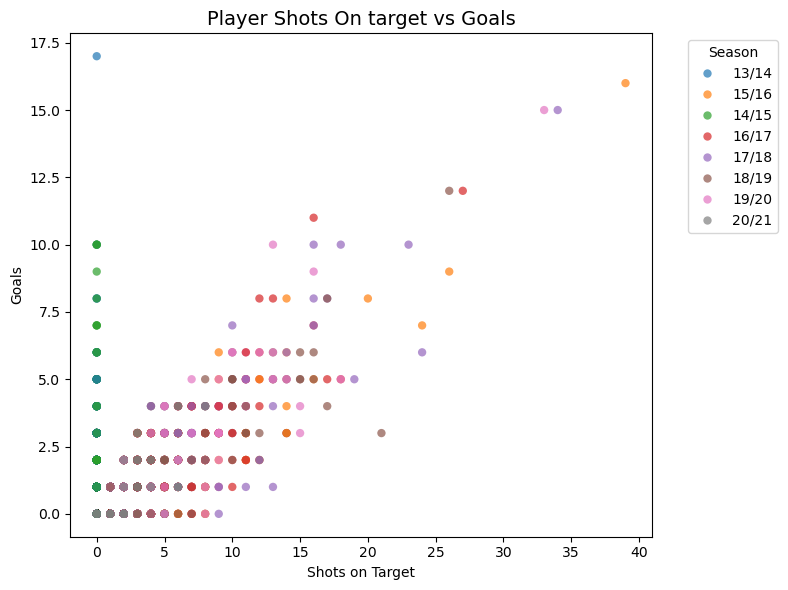

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='shotsOnTarget', y='goals', hue='season year', palette='tab10', alpha=0.7, edgecolor='none')

plt.title("Player Shots On target vs Goals", fontsize=14)
plt.xlabel("Shots on Target")
plt.ylabel("Goals")
plt.legend(title="Season", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

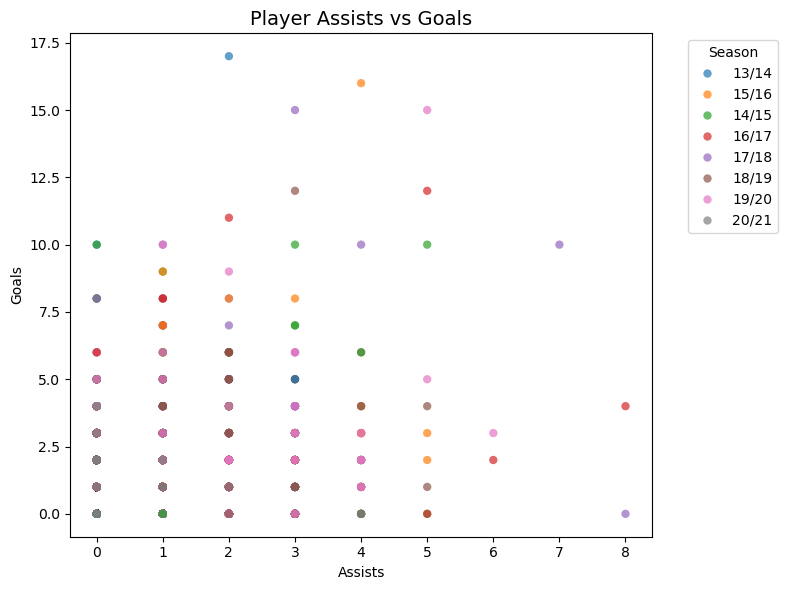

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='assists', y='goals', hue='season year', palette='tab10', alpha=0.7, edgecolor='none')

plt.title("Player Assists vs Goals", fontsize=14)
plt.xlabel("Assists")
plt.ylabel("Goals")
plt.legend(title="Season", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

##### As we want to predict wether a player is a striker or not, we chose features that relate to ofensive players

In [11]:
features = ['goals', 'assists', 'shotsOnTarget', 'appearances']

player_data = data[['name'] + features].dropna()

# Scale features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(player_data[features])


In [12]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
player_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Inspect cluster centers
print("Cluster Centers (scaled values):")
print(pd.DataFrame(kmeans.cluster_centers_, columns=features))

Cluster Centers (scaled values):
      goals   assists  shotsOnTarget  appearances
0  0.048272 -0.091561       0.054510     0.767573
1  4.109164  1.566068       4.250824     1.508761
2  0.814708  2.544320       0.781530     1.148420
3 -0.331033 -0.356004      -0.337160    -0.726648


##### Using K-means we came up with 4 clusters:

* Cluster 0: Shows players who typically do not play as much These could be any players from any positions
* Cluster 1: Shows players who we beleive to be the forwards but mostly the ones who have a very high performance in the tournament.
* Cluster 2: Shows players who have moderate stats when it comes to forward features. We believe that they are mostly midfielders and who usually create the goal opportunities.
* Cluster 3: Shows players who play a lot games but do not have the forwards statistics at all. These are the players we believe to be defenders. 

In [13]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)
player_data['PCA1'] = pca_result[:, 0]
player_data['PCA2'] = pca_result[:, 1]

##### Each dot = one player

The colors represent the clusters (0–3) from K-Means

Players close together in the plot have similar performance profiles

The PCA plot shows that clusters are fairly distinct, especially the orange cluster (1), who are the players believed to be forwards

The blue cluster (0) is separated toward the lower end, showing players with consistently lower stats

Clusters 2 (green) and 3 (red) overlap slightly, suggesting some statistical similarities. However, 2 is believed to be midfielders and 3 defenders

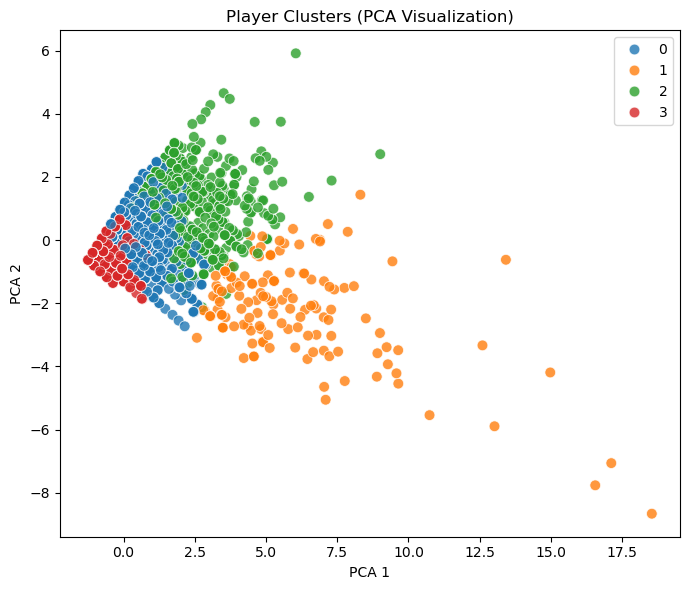

In [14]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=player_data, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=60, alpha=0.8)
plt.title('Player Clusters (PCA Visualization)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.tight_layout()
plt.show()


##### Each dot again = one player

The orange group (Cluster 1) remains tightly packed in one area, confirming that top performers form a distinct group: the forwards.

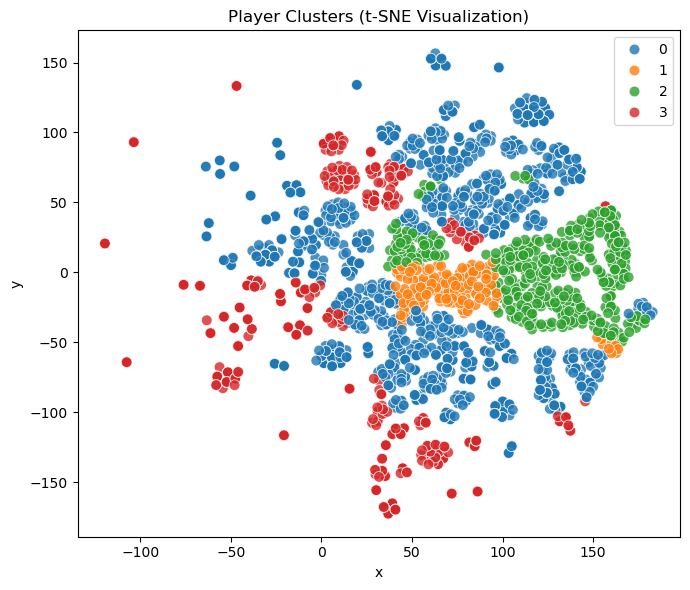

In [15]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_result = tsne.fit_transform(X_scaled)
player_data['TSNE1'] = tsne_result[:, 0]
player_data['TSNE2'] = tsne_result[:, 1]

plt.figure(figsize=(7,6))
sns.scatterplot(data=player_data, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10', s=60, alpha=0.8)
plt.title('Player Clusters (t-SNE Visualization)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
print("\nExample players from each cluster:")
for c in sorted(player_data['Cluster'].unique()):
    print(f"\nCluster {c}:")
    print(player_data[player_data['Cluster'] == c][['name', 'goals', 'assists', 'shotsOnTarget', 'appearances']].head(5))
    print(player_data[player_data['Cluster'] == c][['name', 'goals', 'assists', 'shotsOnTarget', 'appearances']].tail(5))




Example players from each cluster:

Cluster 0:
                  name  goals  assists  shotsOnTarget  appearances
0     Robin van Persie      4      0.0            0.0            6
3   Roman Weidenfeller      0      0.0            0.0            9
4   Roman Weidenfeller      0      0.0            0.0            7
7       Sebastian Kehl      1      0.0            0.0            5
16   Christian Poulsen      0      0.0            0.0            6
                   name  goals  assists  shotsOnTarget  appearances
5649  Rasmus Kristensen      0      0.0            0.0            6
5686          Ansu Fati      1      0.0            1.0            5
5703               Tetê      1      1.0            4.0            3
5707       Ondrej Kolar      0      0.0            0.0            6
5721    Seydouba Soumah      0      0.0            0.0            6

Cluster 1:
                 name  goals  assists  shotsOnTarget  appearances
72  Cristiano Ronaldo     17      2.0            0.0           1

#### What we could improve?

What would improve our project is to first create additional clusters using features that are directly correlated with each group of positions. For example, just as we did for forwards, we should do the same for midfielders and defenders. Then, we could include a “Position” column to run a linear regression t-test and check whether our predicted positions match the players’ actual positions.